# Datasets

<div align="center" style="background-color:rgb(40,40,40); border: solid 2px rgb(255,215,0); border-radius:10px">

### Flood Prediction

</div>

<details>
    <summary>Contents...</summary>

- __MonsoonIntensity__ - Intensidade das monções
- __TopographyDrainage__ - 
- __RiverManagement__ - Gestão de rios
- __Deforestation__ - Desmatamento
- __Urbanization__ - Urbanização
- __ClimateChange__ - Mudanças climáticas
- __DamsQuality__ - Qualidade das barragens
- __Siltation__ - Assoreamento
- __AgriculturalPractices__ - Práticas agrícolas 
- __Encroachments__ - Invasões
- __IneffectiveDisasterPreparedness__ - Preparação ineficaz para desastres
- __DrainageSystems__ - Sistemas de drenagem
- __CoastalVulnerability__ - Vulnerabilidade costeira
- __Landslides__ - Deslizamentos de terra
- __Watersheds__ - Bacias hidrográficas
- __DeterioratingInfrastructure__ - Infraestrutura deteriorada
- __PopulationScore__ - Índice populacional
- __WetlandLoss__ - Perda de áreas úmidas
- __InadequatePlanning__ - Planejamento inadequado
- __PoliticalFactors__ - Fatores políticos
- __FloodProbability__ - Probabilidade de inundação

</details>
<br>
<div align="center" style="background-color:rgb(40,40,40); border: solid 2px rgb(255,215,0); border-radius:10px">

### NASA CME Space Weather Dataset (2000–2020)

</div>

<details>
    <summary>Contents...</summary>

- __activityID__
- __startTime__ 
- __sourceLocation__ 
- __activeRegionNum__ - número da região ativa
- __note__
- __speed__
- __halfAngle__ - meio ângulo
- __type__ -
- __year__ -
- __month__
- __day__
- __latitude__ 
- __longitude__

</details>


In [11]:
# Importando as bibliotecas

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
# import seaborn as sns

# dataSolar =pd.read_csv('datasets/nasa_cme.csv')
dataSolar =pd.read_csv('datasets/DTSN - 01-01-1818_now.csv')
dataFlood =pd.read_csv('datasets/Unknow/flood.csv')
# dataOcean =pd.read_csv('')

print(dataFlood.head())


# Fonte: Royal Observatory of Belgium, SIDC (SILSO)
# Dados: SILSO – Royal Observatory of Belgium, SIDC

   MonsoonIntensity  TopographyDrainage  RiverManagement  Deforestation  \
0                 3                   8                6              6   
1                 8                   4                5              7   
2                 3                  10                4              1   
3                 4                   4                2              7   
4                 3                   7                5              2   

   Urbanization  ClimateChange  DamsQuality  Siltation  AgriculturalPractices  \
0             4              4            6          2                      3   
1             7              9            1          5                      5   
2             7              5            4          7                      4   
3             3              4            1          4                      6   
4             5              8            5          2                      7   

   Encroachments  ...  DrainageSystems  CoastalVulnerability  

In [5]:
# Correção de colunas:

newcolumns = ['ano', 'mes', 'dia', 'data_decimal', 'num_manchas', 'desvio_padrao', 'num_observacoes', 'status']

# Lendo o arquivo adicionando os nomes das colunas e tratando o ponto e vírgula e espaços
dataSolar =pd.read_csv('datasets/DTSN - 01-01-1818_now.csv', sep=';', names=newcolumns, skipinitialspace=True)

In [6]:
# Tratamendo dos dados:

# Tratar os valores ausentes (-1) para que não apareçam no gráfico:
dataSolar['num_manchas'] = dataSolar['num_manchas'].replace(-1, None)

## Remover NaN de colunas
# i =dataSolar['startTime'].notna() & dataSolar['speed'].notna() # vetor booleano auxiliar onde não ha NaN
# dataSolar =dataSolar[i]
# data_clean =dataSolar.dropna(subset=['speed', 'halfAngle'])#.copy()

## Remover Null ou None:
dataSolar =dataSolar[dataSolar['num_manchas'].notnull()]

# Modificar campos de ano, mes e dia para um campo tipo datetime:
dataSolar['data'] =pd.to_datetime(dataSolar[['ano', 'mes', 'dia']].rename(columns={'ano':'year', 'mes':'month', 'dia':'day'}))
dataSolar =dataSolar.drop(columns=['ano', 'mes', 'dia'])

## Correção de tipagem
# data_clean['speed'] =data_clean['speed'].astype(float)
# data_clean['halfAngle'] =data_clean['halfAngle'].astype(float)

# dataSolar['startTime'] =pd.to_datetime(dataSolar['startTime'], utc=True) # Conversao para datetime
# dataSolar =dataSolar.sort_values('startTime') # Ordenar

# dataSolar['startTime'] =dataSolar['startTime'].dt.strftime('%Y%m%d').astype(int) # Conversao para int
# print(dataSolar['startTime'].iloc[0:12])

# Linhas e colunas:
# print(dataSolar.shape)
# print(data_clean.shape)

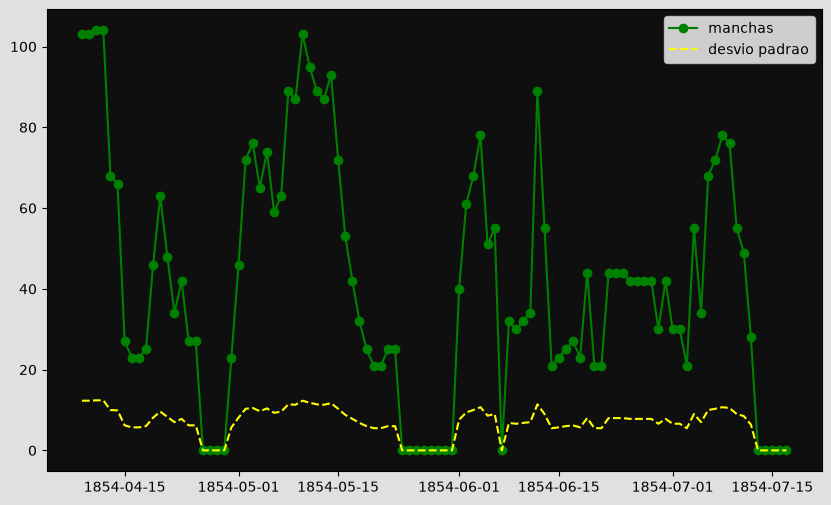

In [10]:
## 3. Grafico
# Redimensionamento
plt.figure(figsize=(10, 6))

# Altera o fundo interno (área do gráfico)
plt.gca().set_facecolor('#0F0F0F') 

# Altera o fundo externo (área da figura completa)
plt.gcf().patch.set_facecolor('#e0e0e0') 

# print(dataSolar[['startTime', 'speed']].head(12))
x =dataSolar['data'].iloc[10000:10100]
y =dataSolar['num_manchas'].iloc[10000:10100]
y2 =dataSolar['desvio_padrao'].iloc[10000:10100]

# df = df.sort_values('data_grafico') # Ordenar por data
plt.plot(x,y, label="manchas", color='green', linestyle='-', marker='o')
plt.plot(x,y2, label="desvio padrao", color='yellow', linestyle='--')
# sns.scatterplot(data=data_clean, x ='speed', y ='halfAngle', hue='type', palete='viridis', s =100)
# sns.lineplot(data=data_clean, x ='speed', y ='halfAngle', hue='type', palete='viridis', s =100)

# plt.title('Comparação entre Velocidade e Ângulo de Abertura das CMEs')
# plt.xlabel('Velocidade (km/s)')
# plt.ylabel('Meio Ângulo (Graus)')
# plt.grid(True, linestyle='--', alpha=0.5)

plt.legend()
plt.show()